# Titanic: select and validate a small soft-voting ensemble

Run cells from top to bottom after restarting the kernel. Baselines share CV folds;
OOF probabilities include parameter search inside each training fold. Compare only
three motivated small ensembles. Accuracy is the selection objective; prefer a
single model on ties. No automatic calibration is applied.

OOF scores used to choose the composition are development scores. The existing
holdout has already been inspected, so its result is diagnostic, not a new
independent test. Kaggle improvement is not guaranteed.

In [28]:
# Init

import json
from time import perf_counter
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import ConfusionMatrixDisplay

RANDOM_STATE = 42
VALIDATION_SIZE = 0.2
N_REPEATS = 10
SEARCH_ITERATIONS = 10
N_JOBS = 2

# Support running from either the repository root or the notebook directory.
if (Path.cwd() / "training/titanic").is_dir():
    TITANIC_DIR = Path.cwd() / "training/titanic"
else:
    TITANIC_DIR = Path.cwd()
DATA_DIR = TITANIC_DIR / "datasets/titanic"
OUTPUT_DIR = TITANIC_DIR / "outputs/titanic"

NUMERIC_FEATURES = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "HasCabin",
]
CATEGORICAL_FEATURES = [
    "Pclass",
    "Sex",
    "Embarked",
    "Title"
]

In [29]:
# Load

def load_titanic_data(data_dir):
    data_dir.mkdir(parents=True, exist_ok=True)

    base_url = (
        "https://raw.githubusercontent.com/"
        "ageron/handson-ml2/master/datasets/titanic/"
    )

    for filename in ("train.csv", "test.csv"):
        path = data_dir / filename

        if not path.is_file():
            urlretrieve(base_url + filename, str(path))

    train_df = pd.read_csv(data_dir / "train.csv")
    test_df = pd.read_csv(data_dir / "test.csv")

    return train_df, test_df

train_df, test_df = load_titanic_data(DATA_DIR)

print(train_df.shape)
print(test_df.shape)

train_df.head()

(891, 12)
(418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [30]:
# Data splitting

X_full = train_df.drop(columns="Survived")
y_full = train_df["Survived"]

X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=VALIDATION_SIZE, stratify=y_full, random_state=RANDOM_STATE
)

print(X_train.shape)
print(X_val.shape)

(712, 11)
(179, 11)


In [31]:
# First Analyze

X_train.info()

summary = pd.DataFrame({
    "dtype": X_train.dtypes.astype(str),
    "missing": X_train.isnull().sum(),
    "missing_fraction": X_train.isna().mean(),
    "unique_values": X_train.nunique(),
})

summary

<class 'pandas.DataFrame'>
Index: 712 entries, 692 to 507
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Pclass       712 non-null    int64  
 2   Name         712 non-null    str    
 3   Sex          712 non-null    str    
 4   Age          575 non-null    float64
 5   SibSp        712 non-null    int64  
 6   Parch        712 non-null    int64  
 7   Ticket       712 non-null    str    
 8   Fare         712 non-null    float64
 9   Cabin        160 non-null    str    
 10  Embarked     710 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 66.8 KB


,dtype,missing,missing_fraction,unique_values
PassengerId,int64,0,0.000000,712
Pclass,int64,0,0.000000,3
Name,str,0,0.000000,712
Sex,str,0,0.000000,2
Age,float64,137,0.192416,85
SibSp,int64,0,0.000000,7
Parch,int64,0,0.000000,7
Ticket,str,0,0.000000,571
Fare,float64,0,0.000000,226
Cabin,str,552,0.775281,127


In [32]:
# More Splitting

target_distribution = pd.DataFrame({
    "count": y_train.value_counts(),
    "fraction": y_train.value_counts(normalize=True),
}).sort_index()

target_distribution

,count,fraction
Survived,,
0,439,0.616573
1,273,0.383427


In [33]:
# Features

def add_features(df):
    res = df.copy()

    title = (
        res["Name"].str.extract(r",\s*([^.]*)\.", expand=False).str.strip()
    )

    common_titles = ["Mr", "Miss", "Mrs", "Master"]

    res["Title"] = title.where(title.isin(common_titles), "Rare")
    res["HasCabin"] = (res["Cabin"].notna().astype(int))

    return res

add_features(X_train)[
    ["Name", "Title", "Cabin", "HasCabin"]
].head()

,Name,Title,Cabin,HasCabin
692,"Lam, Mr. Ali",Mr,NaN,0
481,"Frost, Mr. Anthony Wood 'Archie'",Mr,NaN,0
527,"Farthing, Mr. John",Mr,C95,1
855,"Aks, Mrs. Sam (Leah Rosen)",Mrs,NaN,0
801,"Collyer, Mrs. Harvey (Charlotte Annie Tate)",Mrs,NaN,0


In [34]:
# Pipeline

def build_model(classifier):
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, NUMERIC_FEATURES),
            ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
        ],
        remainder="drop",
    )

    return Pipeline([
        ("features", FunctionTransformer(add_features, validate=False)),
        ("preprocessing", preprocessor),
        ("classifier", clone(classifier)),
    ])

In [35]:
# CV

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=N_REPEATS,
    random_state=RANDOM_STATE,
)

cv_splits = list(cv.split(X_train, y_train))
print(len(cv_splits))

50


In [37]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

classifiers = {
    "dummy": DummyClassifier(strategy="most_frequent"),
    "logistic_regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "svc": SVC(random_state=RANDOM_STATE),
    "random_forest": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1,),
    "gradient_boosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    "cat_boost": CatBoostClassifier(random_state=RANDOM_STATE, verbose=False, thread_count=1,),
    "light_gbm": LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=1),
    "xgboost": XGBClassifier(random_state=RANDOM_STATE, verbosity=0, n_jobs=1),
}

cv_scores = {}
rows = []

for name, classifier in classifiers.items():
    candidate = build_model(classifier)

    started = perf_counter()
    scores = cross_val_score(
        candidate,
        X_train,
        y_train,
        cv=cv_splits,
        scoring="accuracy",
        n_jobs=N_JOBS,
        error_score="raise",
    )

    cv_scores[name] = scores

    rows.append({"model": name, "mean_accuracy": scores.mean(), "std_accuracy": scores.std(), "seconds": perf_counter() - started})

comparison = (pd.DataFrame(rows).set_index("model").sort_values("mean_accuracy", ascending=False))

print(comparison.round(4))

                     mean_accuracy  std_accuracy  seconds
model                                                    
cat_boost                   0.8296        0.0301  14.8634
svc                         0.8274        0.0279   0.5461
logistic_regression         0.8266        0.0322   1.0158
gradient_boosting           0.8219        0.0326   5.7192
light_gbm                   0.8177        0.0372   0.7615
random_forest               0.8146        0.0314   2.6415
xgboost                     0.8053        0.0366   0.8630
dummy                       0.6166        0.0027   1.3214


In [38]:
# Searching for Parameters


parameters_grids = {
    "logistic_regression": {
        "classifier__C": [0.01, 0.1, 1.0, 10.0],
    },
    "svc": {
        "classifier__C": [0.01, 0.1, 1.0, 10.0],
        "classifier__gamma": ["scale", 0.01],
        "classifier__kernel": ["rbf"],
    },
    "random_forest": {
        "classifier__max_depth": [6, None],
        "classifier__min_samples_leaf": [1, 3],
    },
    "gradient_boosting": {
        "classifier__learning_rate": [0.03, 0.1],
        "classifier__max_iter": [100, 200],
        "classifier__max_leaf_nodes": [7, 15, 31],
        "classifier__min_samples_leaf": [10, 20, 30],
        "classifier__l2_regularization": [0.0, 1.0],
    },
    "cat_boost": {
        "classifier__iterations": [300, 700],
        "classifier__learning_rate": [0.03, 0.1],
        "classifier__depth": [4, 6, 8],
        "classifier__l2_leaf_reg": [1, 3, 10],
    },
    "light_gbm": {
        "classifier__n_estimators": [100, 300],
        "classifier__learning_rate": [0.03, 0.1],
        "classifier__num_leaves": [7, 15, 31],
        "classifier__max_depth": [3, 5, -1],
        "classifier__min_child_samples": [10, 20, 30],
    },
    "xgboost": {
        "classifier__n_estimators": [100, 300],
        "classifier__learning_rate": [0.03, 0.1],
        "classifier__max_depth": [2, 4, 6],
        "classifier__min_child_weight": [1, 3, 5],
        "classifier__subsample": [0.8, 1.0],
        "classifier__colsample_bytree": [0.8, 1.0],
    },
}

## OOF probability quality and overlapping errors

The final search uses the same settings as this nested OOF procedure. Brier and
log loss measure overall probability quality; calibration curves are noisy on
this small dataset. Similar algorithms are not removed solely by their names.

In [39]:
from sklearn.model_selection import (
    StratifiedKFold,
    RandomizedSearchCV,
    ParameterGrid,
    cross_val_predict,
)

inner_cv = StratifiedKFold(
    n_splits=3, shuffle=True, random_state=RANDOM_STATE,
)

outer_cv = list(
    StratifiedKFold(
        n_splits=5, shuffle=True, random_state=RANDOM_STATE,
    ).split(X_train, y_train)
)

def make_search(name):
    classifier = clone(classifiers[name])

    if name == "svc":
        classifier.set_params(probability=True)

    params = parameters_grids[name]

    return RandomizedSearchCV(
        estimator=build_model(classifier),
        param_distributions=params,
        # Для текущего словаря со списками значений.
        n_iter=min(SEARCH_ITERATIONS, len(ParameterGrid(params))),
        scoring="accuracy",
        cv=inner_cv,
        random_state=RANDOM_STATE,
        n_jobs=1,
        refit=True,
        error_score="raise",
    )

oof_probabilities = pd.DataFrame(index=X_train.index)

for name in parameters_grids:
    print("Evaluating:", name)

    started = perf_counter()
    probabilities = cross_val_predict(
        make_search(name),
        X_train,
        y_train,
        cv=outer_cv,
        method="predict_proba",
        n_jobs=N_JOBS,
    )

    oof_probabilities[name] = probabilities[:, 1]
    print(f"  {perf_counter() - started:.1f} seconds")

Evaluating: logistic_regression
  1.9 seconds
Evaluating: svc
  1.9 seconds
Evaluating: random_forest
  3.5 seconds
Evaluating: gradient_boosting
  17.5 seconds
Evaluating: cat_boost
  48.0 seconds
Evaluating: light_gbm
  3.3 seconds
Evaluating: xgboost
  3.4 seconds


                     accuracy   brier  log_loss
model                                          
xgboost                0.8202  0.1249    0.3984
light_gbm              0.8216  0.1248    0.3998
gradient_boosting      0.8188  0.1244    0.3998
cat_boost              0.8202  0.1258    0.4061
random_forest          0.8272  0.1247    0.4080
logistic_regression    0.8315  0.1317    0.4228
svc                    0.8315  0.1351    0.4360


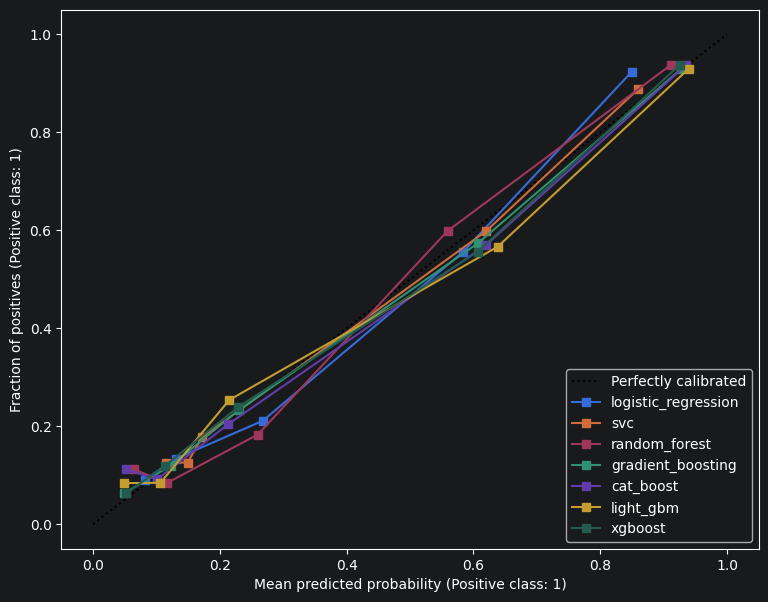

In [40]:
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    log_loss,
)

rows = []
fig, ax = plt.subplots(figsize=(9, 7))

for name in oof_probabilities:
    p = oof_probabilities[name].to_numpy()

    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_train, p >= 0.5),
        "brier": brier_score_loss(y_train, p),
        "log_loss": log_loss(y_train, p),
    })

    CalibrationDisplay.from_predictions(
        y_train,
        p,
        n_bins=5,
        strategy="quantile",
        name=name,
        ax=ax,
    )

quality = (
    pd.DataFrame(rows)
    .set_index("model")
    .sort_values("log_loss")
)

print(quality.round(4))
plt.show()

In [41]:
oof_labels = oof_probabilities.ge(0.5)

oof_errors = oof_labels.ne(
    y_train.to_numpy(),
    axis=0,
).astype(int)

print("Корреляция ошибок:")
errors_correlation = oof_errors.corr()
print(errors_correlation.round(2))

Корреляция ошибок:
                     logistic_regression   svc  random_forest  \
logistic_regression                 1.00  0.86           0.78   
svc                                 0.86  1.00           0.80   
random_forest                       0.78  0.80           1.00   
gradient_boosting                   0.71  0.72           0.88   
cat_boost                           0.70  0.72           0.83   
light_gbm                           0.68  0.71           0.82   
xgboost                             0.70  0.70           0.84   

                     gradient_boosting  cat_boost  light_gbm  xgboost  
logistic_regression               0.71       0.70       0.68     0.70  
svc                               0.72       0.72       0.71     0.70  
random_forest                     0.88       0.83       0.82     0.84  
gradient_boosting                 1.00       0.89       0.90     0.93  
cat_boost                         0.89       1.00       0.88     0.87  
light_gbm                   

In [43]:
# Compare three small ensembles suggested by the observed error patterns.
# The selection below uses development OOF data, not X_val or Kaggle scores.
boosting_names = ["gradient_boosting", "cat_boost", "light_gbm", "xgboost"]
best_boosting = quality.loc[boosting_names, "log_loss"].idxmin()
best_single_name = quality.sort_values(
    ["accuracy", "log_loss"], ascending=[False, True],
).index[0]

ensemble_specs = {
    "linear_boost": (["logistic_regression", best_boosting], [1, 1]),
    "svc_boost": (["svc", best_boosting], [1, 1]),
    "linear_forest_boost": (
        ["logistic_regression", "random_forest", best_boosting], [1, 1, 1],
    ),
}

candidate_rows = []

def record_candidate(name, probability, n_models, role):
    candidate_rows.append({
        "candidate": name,
        "role": role,
        "n_models": n_models,
        "accuracy": accuracy_score(y_train, probability >= 0.5),
        "log_loss": log_loss(y_train, probability),
        "brier": brier_score_loss(y_train, probability),
    })

record_candidate(
    "best_single", oof_probabilities[best_single_name].to_numpy(), 1, "single",
)
for name, (members, weights) in ensemble_specs.items():
    probability = np.average(oof_probabilities[members], axis=1, weights=weights)
    record_candidate(name, probability, len(members), "ensemble")

# Keep the previous large ensembles as references, not extra search candidates.
record_candidate(
    "all_seven_reference", oof_probabilities.mean(axis=1).to_numpy(), 7, "reference",
)
old_members = ["logistic_regression", "svc", "random_forest", best_boosting]
record_candidate(
    "four_models_reference", oof_probabilities[old_members].mean(axis=1).to_numpy(),
    4, "reference",
)

ensemble_comparison = pd.DataFrame(candidate_rows).set_index("candidate")
# Primary objective: accuracy. On ties prefer fewer members, then lower log loss.
ranking = ensemble_comparison.sort_values(
    ["accuracy", "n_models", "log_loss"], ascending=[False, True, True],
)
ensemble_name = ranking.loc[ranking["role"] == "ensemble"].index[0]
keep_names, voting_weights = ensemble_specs[ensemble_name]
selection_ranking = ranking.loc[ranking["role"].isin(["single", "ensemble"])]
selected_candidate = selection_ranking.index[0]

print(ranking.round(4))
print("Best single:", best_single_name)
print("Ensemble:", ensemble_name, keep_names, "weights:", voting_weights)
print("Default submission candidate:", selected_candidate)
print("These OOF results are used for selection; they are not an independent final score.")

                            role  n_models  accuracy  log_loss   brier
candidate                                                             
best_single               single         1    0.8315    0.4228  0.1317
svc_boost               ensemble         2    0.8301    0.4021  0.1241
four_models_reference  reference         4    0.8287    0.4006  0.1234
linear_forest_boost     ensemble         3    0.8230    0.3982  0.1230
all_seven_reference    reference         7    0.8230    0.3942  0.1218
linear_boost            ensemble         2    0.8202    0.3999  0.1240
Best single: logistic_regression
Ensemble: svc_boost ['svc', 'xgboost'] weights: [1, 1]
Default submission candidate: best_single
These OOF results are used for selection; they are not an independent final score.


## Fit the chosen ensemble and compare with the best single model

`keep_names` controls the actual VotingClassifier members. If the best small
ensemble does not improve development accuracy, `submission.csv` uses the best
single model. `ensemble_submission.csv` always contains the ensemble candidate.

In [44]:
from sklearn.ensemble import VotingClassifier

# Use exactly the same search budget, folds and probability settings as in OOF.
tuned_models = {}
final_tuning_rows = []
for name in dict.fromkeys(keep_names + [best_single_name]):
    search = make_search(name)
    search.set_params(n_jobs=N_JOBS)
    search.fit(X_train, y_train)
    tuned_models[name] = search.best_estimator_
    final_tuning_rows.append({
        "model": name,
        "inner_cv_accuracy": search.best_score_,
        "best_params": search.best_params_,
    })

tuning_comparison = pd.DataFrame(final_tuning_rows).set_index("model")
print(tuning_comparison)

ensemble = VotingClassifier(
    estimators=[(name, clone(tuned_models[name])) for name in keep_names],
    voting="soft",
    weights=voting_weights,
    n_jobs=1,
)
ensemble.fit(X_train, y_train)
best_single_model = tuned_models[best_single_name]
selected_model = ensemble if selected_candidate != "best_single" else best_single_model
print("Selected model:", selected_candidate)

                     inner_cv_accuracy  \
model                                    
svc                           0.827270   
xgboost                       0.837104   
logistic_regression           0.825881   

                                                           best_params  
model                                                                   
svc                  {'classifier__kernel': 'rbf', 'classifier__gam...  
xgboost              {'classifier__subsample': 1.0, 'classifier__n_...  
logistic_regression                             {'classifier__C': 1.0}  
Selected model: best_single


                     accuracy  log_loss   brier
model                                          
logistic_regression    0.8268    0.4241  0.1309
svc_boost              0.8380    0.4260  0.1309
              precision    recall  f1-score   support

           0      0.843     0.882     0.862       110
           1      0.797     0.739     0.767        69

    accuracy                          0.827       179
   macro avg      0.820     0.810     0.815       179
weighted avg      0.826     0.827     0.825       179



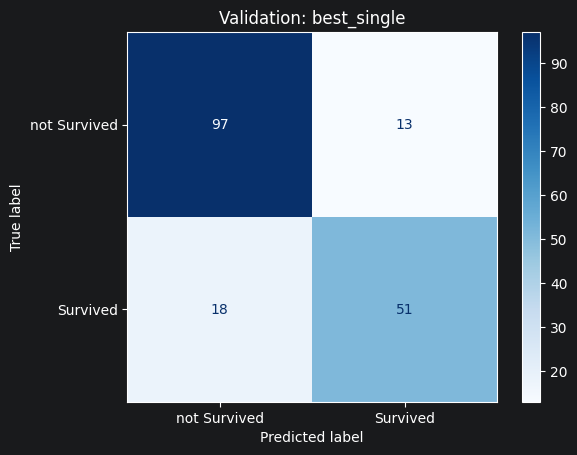

In [45]:
# Diagnostic only: this holdout has already been inspected in prior experiments.
# Do not switch candidates or tune weights based on this table.
validation_rows = []
for name, model in [(best_single_name, best_single_model), (ensemble_name, ensemble)]:
    probability = model.predict_proba(X_val)[:, 1]
    validation_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_val, model.predict(X_val)),
        "log_loss": log_loss(y_val, probability),
        "brier": brier_score_loss(y_val, probability),
    })
validation_comparison = pd.DataFrame(validation_rows).set_index("model")
print(validation_comparison.round(4))

val_predictions = selected_model.predict(X_val)
print(classification_report(y_val, val_predictions, digits=3, zero_division=0))
ConfusionMatrixDisplay.from_predictions(
    y_val, val_predictions, display_labels=["not Survived", "Survived"], cmap="Blues",
)
plt.title(f"Validation: {selected_candidate}")
plt.show()

In [46]:
# Analyzing Model Errors

validation_details = add_features(X_val)

validation_details["actual"] = y_val
validation_details["predictions"] = val_predictions

errors = validation_details.loc[
    validation_details["actual"] != validation_details["predictions"]
].copy()

print("errors: ", len(errors))

errors[[
    "PassengerId",
    "Sex",
    "Age",
    "Pclass",
    "Title",
    "HasCabin",
    "actual",
    "predictions",
]].head(15)

errors:  31


,PassengerId,Sex,Age,Pclass,Title,HasCabin,actual,predictions
553,554,male,22.0,3,Mr,0,1,0
536,537,male,45.0,1,Rare,1,0,1
712,713,male,48.0,1,Mr,1,1,0
455,456,male,29.0,3,Mr,0,1,0
65,66,male,NaN,3,Master,0,1,0
489,490,male,9.0,3,Master,0,1,0
297,298,female,2.0,1,Miss,1,0,1
40,41,female,40.0,3,Mrs,0,0,1
564,565,female,NaN,3,Miss,0,0,1
502,503,female,NaN,3,Miss,0,0,1


In [47]:
# Fit on all labeled rows once the composition and parameters have been fixed.
final_ensemble = clone(ensemble)
final_ensemble.fit(X_full, y_full)
if selected_candidate == "best_single":
    final_model = clone(selected_model)
    final_model.fit(X_full, y_full)
else:
    final_model = final_ensemble

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def save_submission(model, filename):
    predictions = model.predict(test_df)
    assert len(predictions) == len(test_df)
    assert np.isin(predictions, [0, 1]).all()
    result = pd.DataFrame({
        "PassengerId": test_df["PassengerId"].to_numpy(),
        "Survived": predictions.astype(int),
    })
    assert list(result.columns) == ["PassengerId", "Survived"]
    assert result.shape == (418, 2)
    assert not result.isna().any().any()
    assert result["PassengerId"].is_unique
    assert np.array_equal(result["PassengerId"], test_df["PassengerId"])
    destination = OUTPUT_DIR / filename
    result.to_csv(destination, index=False)
    pd.testing.assert_frame_equal(pd.read_csv(destination), result)
    print("File:", destination.resolve())
    return result

# Explicit ensemble candidate; default file falls back to a better single model.
ensemble_submission = save_submission(final_ensemble, "ensemble_submission.csv")
submission = save_submission(final_model, "submission.csv")

comparison.to_csv(OUTPUT_DIR / "model_comparison.csv")
pd.DataFrame(cv_scores).to_csv(OUTPUT_DIR / "cv_scores.csv", index=False)
quality.to_csv(OUTPUT_DIR / "probability_quality.csv")
errors_correlation.to_csv(OUTPUT_DIR / "error_correlation.csv")
ensemble_comparison.to_csv(OUTPUT_DIR / "ensemble_comparison.csv")
validation_comparison.to_csv(OUTPUT_DIR / "validation_comparison.csv")

oof_export = oof_probabilities.copy()
oof_export.insert(0, "PassengerId", X_train["PassengerId"])
oof_export.insert(1, "Survived", y_train)
oof_export.to_csv(OUTPUT_DIR / "oof_probabilities.csv", index=False)

summary = {
    "selected_candidate": selected_candidate,
    "best_single": best_single_name,
    "ensemble_candidate": ensemble_name,
    "ensemble_members": keep_names,
    "ensemble_weights": voting_weights,
    "voting": "soft",
    "random_state": RANDOM_STATE,
    "search_iterations": SEARCH_ITERATIONS,
    "outer_folds": 5,
    "inner_folds": 3,
    "selection_metric": "accuracy; ties: fewer models, then log loss",
    "calibration": "SVC probability=True; no additional calibration",
    "evaluation_limit": "OOF used for candidate selection; holdout previously inspected",
    "best_params": tuning_comparison["best_params"].to_dict(),
    "default_csv": "submission.csv",
    "ensemble_csv": "ensemble_submission.csv",
}
(OUTPUT_DIR / "ensemble_summary.json").write_text(
    json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8",
)
print("Default file represents:", selected_candidate)

File: /home/kolja/home/kole4ka_bot/first-ml-project/training/titanic/outputs/titanic/ensemble_submission.csv
File: /home/kolja/home/kole4ka_bot/first-ml-project/training/titanic/outputs/titanic/submission.csv
Default file represents: best_single
